In [35]:
# Exercise: ex19_random_forest_regression
# Random Forest

In [1]:
#a)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [3]:
y = df['petal length (cm)']
X = df.drop('petal length (cm)', axis=1)
X['species'] = iris.target

In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), ['species']),
        ('num', 'passthrough', [col for col in X.columns if col != 'species'])
    ]
)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [7]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"Random Forest R2 Score: {r2:.4f}")

Random Forest R2 Score: 0.9708


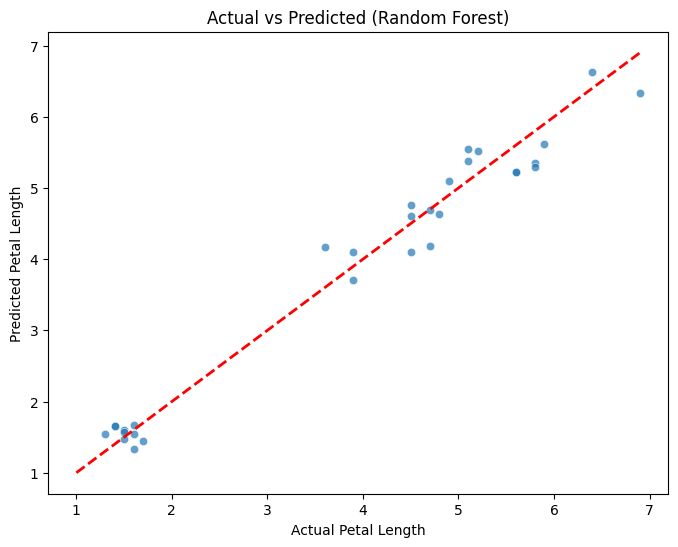

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) 
plt.xlabel("Actual Petal Length")
plt.ylabel("Predicted Petal Length")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [9]:
ohe_features = model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(['species'])
num_features = [col for col in X.columns if col != 'species']
all_features = list(ohe_features) + num_features

In [10]:
importances = model.named_steps['regressor'].feature_importances_
df_imp = pd.DataFrame({'feature': all_features, 'importance': importances}).sort_values('importance', ascending=False)

/tmp/ipykernel_825079/3097277715.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x='importance', y='feature', palette='viridis')


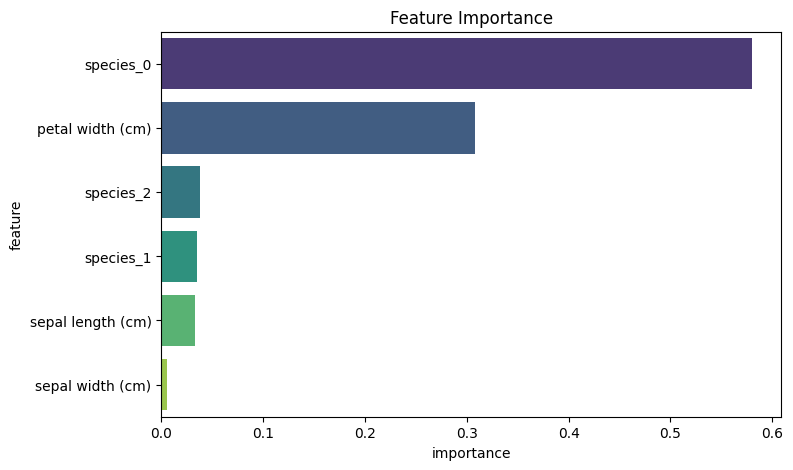

In [11]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_imp, x='importance', y='feature', palette='viridis')
plt.title("Feature Importance")
plt.show()